<a href="https://colab.research.google.com/github/GustavoBLuz/Projetos_Aula/blob/Exercicios_Aula/Cliente4_E_commerce_Tech_Mart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cliente 4 — E-commerce Tech Mart

**Análise CRISP-DM — Regressão Linear (Preço x Demanda)**

Este notebook segue todas as fases do processo CRISP-DM e está pronto para rodar no Google Colab / Jupyter.

## 1) Definição do Problema de Negócio

Pergunta: Consigo prever o faturamento/vendas de um produto de E-commerce a partir do seu preço?

Objetivo: Criar um modelo simples de regressão linear que ajude a empresa de E-commerce a otimizar a precificação para maximizar as vendas.

Escopo: Regressão linear simples (1 variável preditora: Preço).

## 2) Pré-Processamento dos Dados

Importação de bibliotecas, configurações e tratamentos iniciais.

In [ ]:

# Imports e configurações
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (8,5)
sns.set_style('whitegrid')
print('Bibliotecas importadas com sucesso.')


Bibliotecas importadas com sucesso.


## 3) Extração e Carregamento

- Carregue seus dados aqui. Se não tiver um arquivo, o bloco abaixo gera um dataset simulado de exemplo. Substitua `df` usando `pd.read_csv('seu_arquivo.csv')` se preferir.

- Identificamos automaticamente as colunas numéricas e selecionamos as prováveis colunas de entrada (Preço) e alvo (Demanda). Devido a acharmos "furos" dentro das planilhas ao checar manualmente, foi feito uma varredura para limpar os dados e remover qualquer linha que tenha um valor Null dentro dela, evitando contaminar as predições.

In [ ]:
# Opção A: carregar CSV (descomente e ajuste o caminho se tiver o arquivo)
# PATH = 'dataset_1_regressao_limpo.csv'
# df = pd.read_csv(PATH)

# Opção B: gerar dados simulados (exemplo)
# caminho do dataset (já presente no ambiente)
PATH = "dataset_4_regressao_limpo.csv"

df = pd.read_csv(PATH)
display(df.head(100))
print("\nInformação do dataframe:")
display(df.info())
print("\nDescrição estatística:")
display(df.describe().T)

# heurística simples para detectar colunas X e y
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
def pick_columns(df):
    candidates = {c.lower(): c for c in df.columns}
    x_col = None
    y_col = None
    for key in candidates:
        # Preço and Demanda
        if any(k in key for k in ["preco", "price"]):
            x_col = candidates[key]
        if any(k in key for k in ["demanda", "demand", "venda", "sales"]):
            y_col = candidates[key]
    if x_col is None or y_col is None:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        if len(num_cols) >= 2:
            x_col = x_col or num_cols[0]
            y_col = y_col or [c for c in num_cols if c != x_col][0]
    return x_col, y_col

x_col, y_col = pick_columns(df)
print('Colunas detectadas:', x_col, '->', y_col)

# remover NaNs nas colunas selecionadas
df_model = df[[x_col, y_col]].dropna().copy()
print('\nObservações após remoção de NaN:', len(df_model))

,preco_produto,demanda_unidades,numero_concorrentes,investimento_marketing,categoria,sazonalidade,elasticidade_estimada
0,15.637263,534.062838,2.0,5732.393995,Roupas,Média,0.587556
1,23.106528,270.390393,6.0,NaN,Casa,Média,1.714843
2,31.640140,210.602092,7.0,5516.529144,Eletrônicos,NaN,3.014786
3,25.273127,393.605292,6.0,5738.636804,Casa,Baixa,1.288484
4,25.670877,247.189980,2.0,NaN,Esporte,Média,2.083966
5,NaN,460.288517,3.0,6555.386728,Casa,Alta,0.764791
6,31.339171,200.000000,4.0,5910.782354,Esporte,Média,3.144404
7,18.881401,NaN,4.0,6614.251136,Esporte,NaN,0.928646
8,16.162370,536.069004,4.0,6631.920064,Roupas,Baixa,0.605014
9,28.708592,200.000000,2.0,5686.859587,Esporte,Média,2.880466



Informação do dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   preco_produto           48 non-null     float64
 1   demanda_unidades        49 non-null     float64
 2   numero_concorrentes     49 non-null     float64
 3   investimento_marketing  47 non-null     float64
 4   categoria               49 non-null     object 
 5   sazonalidade            48 non-null     object 
 6   elasticidade_estimada   50 non-null     float64
dtypes: float64(5), object(2)
memory usage: 2.9+ KB


None


Descrição estatística:


,count,mean,std,min,25%,50%,75%,max
preco_produto,48.0,21.763478,5.451756,15.070912,18.176242,19.990708,25.063332,35.000000
demanda_unidades,49.0,392.101775,121.660725,200.000000,296.581584,398.099623,484.220016,599.915513
numero_concorrentes,49.0,4.224490,1.782616,1.000000,3.000000,4.000000,5.000000,8.000000
investimento_marketing,47.0,6064.051779,916.789632,4251.431614,5571.538594,6033.351230,6758.415747,7877.637987
elasticidade_estimada,50.0,1.344909,0.856253,0.504116,0.766490,0.953111,1.654763,3.511712


Colunas detectadas: preco_produto -> demanda_unidades

Observações após remoção de NaN: 47


## 4) Análise Exploratória (Exploratory Data Analysis/EDA)
- Gráfico de dispersão: O objetivo do gráfico é visualizar a tendência geral, se a demanda aumenta ou diminui com base no preço, e isso vai definir se a regressão linear é adequada para modelar os dados. Esperamos uma relação inversa (quanto maior o preço, menor a demanda).
- Correlação de Pearson: Analisaremos a correlação entre Preço e Demanda. Um R próximo de -1 indicaria uma forte relação inversa, confirmando nossa expectativa para produtos de E-commerce.
- Estatísticas descritivas: Esta análise mostrará a distribuição dos preços e da demanda no dataset, incluindo médias, desvios padrão, valores mínimos e máximos. Isso nos dará uma visão geral do comportamento dessas variáveis.

In [ ]:

# Informações gerais
print('Dimensões do dataset:', df.shape)
print('\nTipos de dados:')
display(df_model.dtypes)
print('\nResumo estatístico:')
display(df_model.describe().T)


Dimensões do dataset: (50, 7)

Tipos de dados:


,0
preco_produto,float64
demanda_unidades,float64



Resumo estatístico:


,count,mean,std,min,25%,50%,75%,max
preco_produto,47.0,21.824798,5.493938,15.070912,17.851159,20.202968,25.133264,35.000000
demanda_unidades,47.0,391.578360,123.702120,200.000000,294.113359,398.099623,493.999834,599.915513


### Visualização
- Histogramas
- Gráfico de dispersão (Preço x Demanda)
- Matriz de correlação

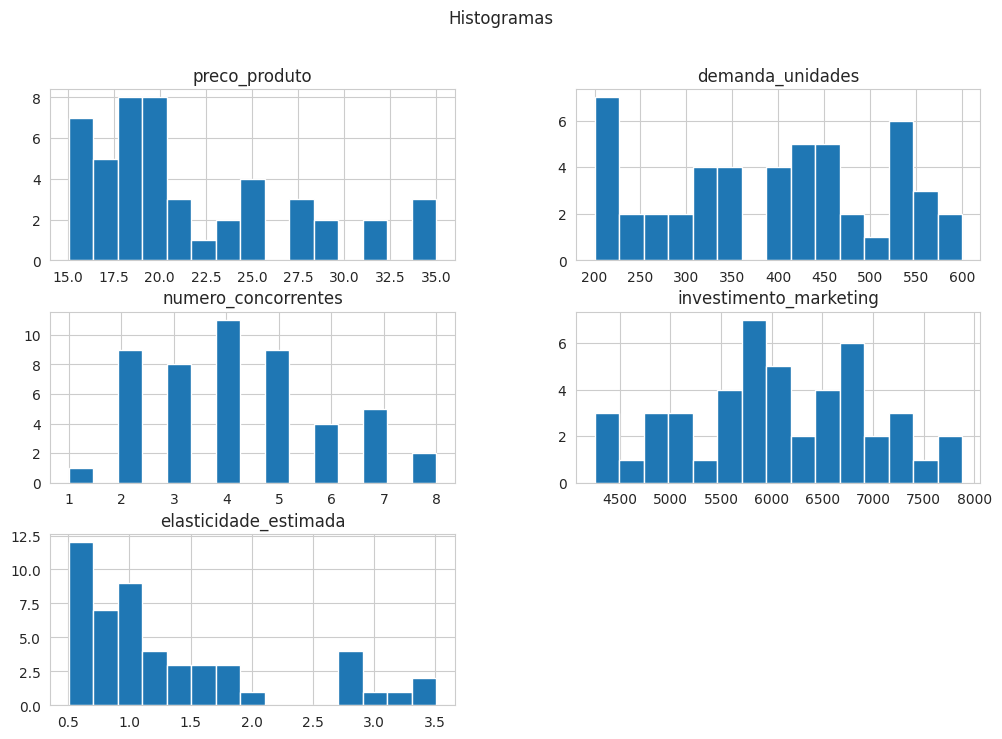

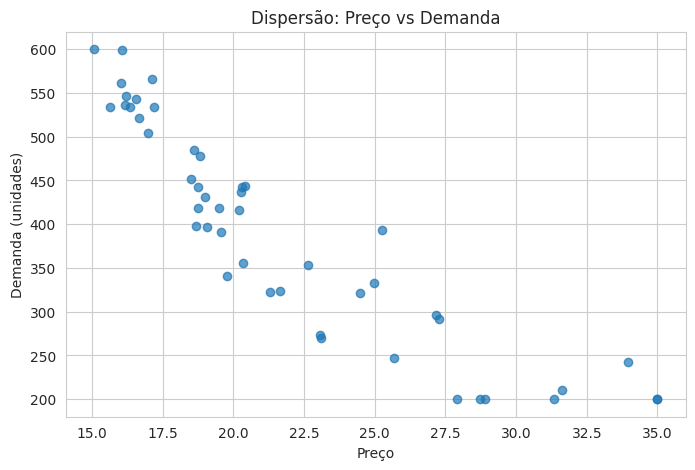

Matriz de correlação:


,preco_produto,demanda_unidades,numero_concorrentes,investimento_marketing,elasticidade_estimada
preco_produto,1.000000,-0.904620,0.115609,-0.077826,0.968790
demanda_unidades,-0.904620,1.000000,-0.064874,0.039373,-0.910840
numero_concorrentes,0.115609,-0.064874,1.000000,-0.234305,0.095459
investimento_marketing,-0.077826,0.039373,-0.234305,1.000000,-0.134918
elasticidade_estimada,0.968790,-0.910840,0.095459,-0.134918,1.000000


In [ ]:
# Histograma das variáveis
df.hist(bins=15, figsize=(12,8))
plt.suptitle('Histogramas')
plt.show()

# Scatter plot
plt.scatter(df_model[x_col], df_model[y_col], alpha=0.7)
plt.xlabel('Preço')
plt.ylabel('Demanda (unidades)')
plt.title('Dispersão: Preço vs Demanda')
plt.show()

# Correlação
numeric_df = df.select_dtypes(include=[np.number]) # Select only numeric columns
corr = numeric_df.corr()
print('Matriz de correlação:')
display(corr)

## 5) Aprendizado dos Algoritmos

Usaremos Regressão Linear Simples para modelar a relação:  

$y = \beta_0 + \beta_1 x + \epsilon$  

Onde:
- $x$ = Preço
- $y$ = Demanda

### 6) Regressão Linear com Scikit-learn
#### Baseado na quantidade limitada de 47 dados, iremos separar em 80% de Treino e 20% para Teste (80% treino / 20% teste), esperamos ter uma precisão mais exata e confiavel através dessa.

#### Criando o modelo de regressão e treinando

In [ ]:
# Preparar X e y
X = df_model[[x_col]].values
y = df_model[y_col].values

# Separar em treino e teste (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f'Tamanho treino: {len(X_train)}, tamanho teste: {len(X_test)}')

Tamanho treino: 37, tamanho teste: 10


In [ ]:

# Criando o modelo
modelo = LinearRegression()

# Treinando o modelo
modelo.fit(X_train, y_train)

# Coeficientes
b1 = modelo.coef_[0]
b0 = modelo.intercept_
print(f'Intercepto (b0): {b0:.4f}')
print(f'Coeficiente angular (b1): {b1:.4f}')


Intercepto (b0): 820.6865
Coeficiente angular (b1): -19.3762


## 7) Validação, Avaliação e Otimização

Calcular previsões e métricas de avaliação.

In [ ]:

# Previsões no conjunto de teste
y_pred = modelo.predict(X_test)

# Métricas
mse = mean_squared_error(y_test, y_pred)      #MSE, Média dos erros ao quadrado
rmse = np.sqrt(mse)                           # RMSE raiz do MSE
mae = mean_absolute_error(y_test, y_pred)     #MAE, Média das diferenças absolutas
r2 = r2_score(y_test, y_pred)                 #Calcula o R² dentro do teste, para qualidade de novos dados
score_method = modelo.score(X_test, y_test)   # .score() retorna R² para regressão

#Mostra os dados calculados, R² de treino, teste, o ajuste feito, o MAE e o RMSE e o Score
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² (r2_score): {r2:.4f}')
print(f'.score() do modelo: {score_method:.4f}  (equivalente ao R²)')


MSE: 2843.2361
RMSE: 53.3220
MAE: 46.0996
R² (r2_score): 0.7796
.score() do modelo: 0.7796  (equivalente ao R²)


### Análise dos Resíduos e Visualizações de Avaliação

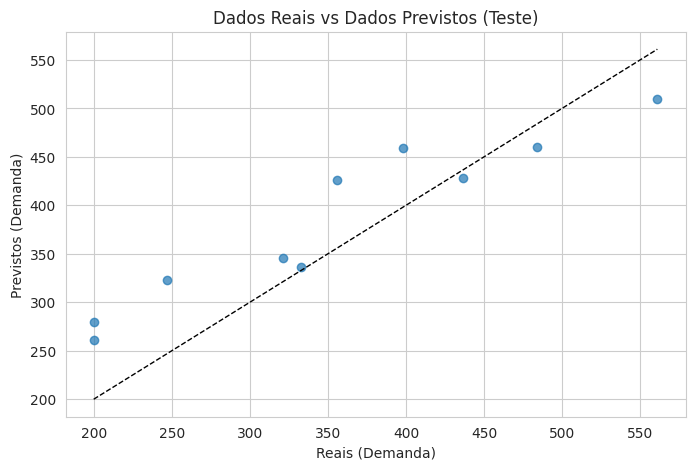

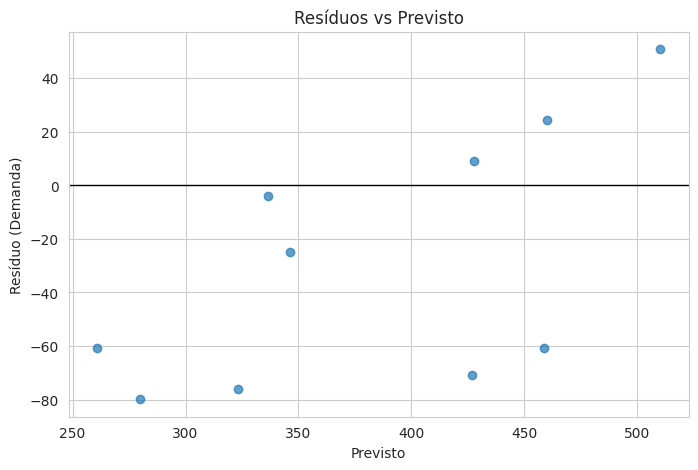

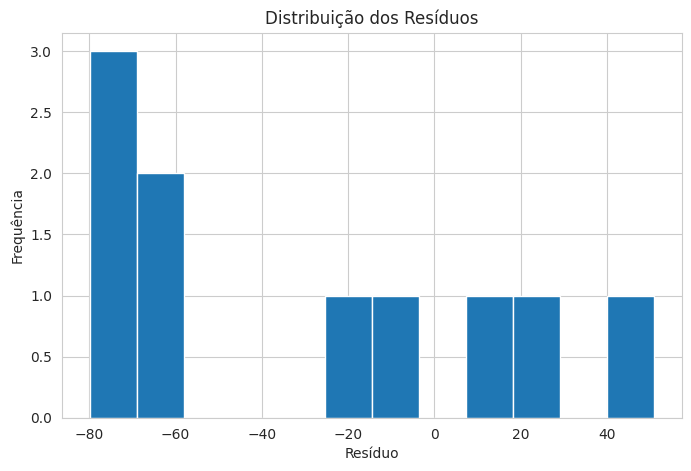

In [ ]:
# Gráfico: pontos de teste (real vs previsto)
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Reais (Demanda)')
plt.ylabel('Previstos (Demanda)')
plt.title('Dados Reais vs Dados Previstos (Teste)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', linewidth=1)
plt.show()

# Residuals
residuos = y_test - y_pred
plt.scatter(y_pred, residuos, alpha=0.7)
plt.axhline(0, color='k', linewidth=1)
plt.xlabel('Previsto')                    #nome do eixo x (com a mesma label do arquivo)
plt.ylabel('Resíduo (Demanda)')            #nome do eixo y (com a mesma label do arquivo)
plt.title('Resíduos vs Previsto')
plt.show()                                #printa o grafico

# Histograma dos resíduos
plt.hist(residuos, bins=12)
plt.title('Distribuição dos Resíduos')
plt.xlabel('Resíduo')
plt.ylabel('Frequência')
plt.show()

### O que faz a função `.score()`?

No caso de regressão, `.score(X, y)` retorna o **coeficiente de determinação R²**, que mede a proporção da variância em y explicada por X. Valores próximos de 1 indicam bom ajuste; valores próximos de 0 indicam ajuste ruim.

## 8) Previsão / Predição

Exemplos de predição com novos valores de temperatura.

In [ ]:
# Predição para novos preços
novos_precos = np.array([[15.0], [20.0], [25.0], [30.0]]) # Exemplo de novos preços para prever
previsoes = modelo.predict(novos_precos)
for preco, demanda_prevista in zip(novos_precos.flatten(), previsoes):
    print(f'Preço R${preco:.2f} -> Demanda prevista: {demanda_prevista:.2f} unidades')

Preço R$15.00 -> Demanda prevista: 530.04 unidades
Preço R$20.00 -> Demanda prevista: 433.16 unidades
Preço R$25.00 -> Demanda prevista: 336.28 unidades
Preço R$30.00 -> Demanda prevista: 239.40 unidades


## 9) Salvando o resultado do seu trabalho

- Salvar o modelo treinado e registrar métricas em arquivo para reprodução/implantação, para assim poder enviar ao cliente os resultados encontrados junto dos comentários.

In [ ]:
# Salvar modelo com pickle e joblib
pickle.dump(modelo, open('modelo_regressao_pickle.sav', 'wb'))
joblib.dump(modelo, 'modelo_regressao_joblib.pkl')

# Salvar métricas em CSV
metrics = {
    'MSE': [mse],
    'RMSE': [rmse],
    'MAE': [mae],
    'R2': [r2]
}
df_metrics = pd.DataFrame(metrics)
df_metrics.to_csv('metricas_modelo_regressao.csv', index=False)

print('Modelo e métricas salvos: modelo_regressao_pickle.sav, modelo_regressao_joblib.pkl, metricas_modelo_regressao.csv')

Modelo e métricas salvos: modelo_regressao_pickle.sav, modelo_regressao_joblib.pkl, metricas_modelo_regressao.csv


## 10) Resumo das Métricas Utilizadas

- MSE (Mean Squared Error): média dos quadrados dos erros. Quanto menor, melhor.
RMSE: raiz do MSE — traz a métrica para a unidade original (aqui: unidades de demanda).
MAE (Mean Absolute Error): média dos erros absolutos — interpretação direta em unidades.
R² (Coeficiente de Determinação): proporção da variância explicada pelo modelo.

---

## 11) Resumo Final e Recomendações

Com base no modelo:
- Interprete o coeficiente e intervalo de confiança (abaixo) para validar significância.
Use o modelo para otimizar a precificação e prever a demanda esperada para diferentes preços.
Considere adicionar outras variáveis (investimento em marketing, número de concorrentes, sazonalidade, promoções, características do produto) para melhorar o modelo.

### Intervalo de Confiança (IC 95%) para os coeficientes

In [ ]:

# Usando statsmodels para IC do coeficiente
X_sm = sm.add_constant(X)  # para todo o conjunto (melhor estimativa dos coeficientes)
est = sm.OLS(y, X_sm).fit()
print(est.summary())
print('\nIntervalo de confiança (95%) para coeficientes:')
print(est.conf_int(alpha=0.05))


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     202.7
Date:                Mon, 08 Sep 2025   Prob (F-statistic):           2.81e-18
Time:                        23:29:42   Log-Likelihood:                -252.54
No. Observations:                  47   AIC:                             509.1
Df Residuals:                      45   BIC:                             512.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        836.1171     32.176     25.985      0.0

## 12) Sugestões baseado nos dados
- O coeficiente encontrado para o preço é negativo, o que indica que a demanda tende a diminuir com o aumento do preço.
- O coeficiente de preço ($\beta_1$) retornado pelo modelo indica a variação esperada na demanda para cada aumento de 1 unidade monetária no preço. Analise o valor exato do coeficiente retornado pelo treinamento do modelo para uma interpretação precisa.

In [ ]:
# Salvar um relatório simples em Markdown
relatorio = f"""# Relatório — Análise de Precificação E-commerce

Equação do modelo:
Demanda = {b0:.3f} + {b1:.3f} * Preço

Métricas (teste):
- MSE: {mse:.3f}
- RMSE: {rmse:.3f}
- MAE: {mae:.3f}
- R2: {r2:.3f}

"""

with open('Relatorio_Ecommerce_Precificacao.md', 'w', encoding='utf-8') as f:
    f.write(relatorio) #salva o relatorio dentro de um .md (também pra fazer download dentro do colab)

print('Relatório salvo: Relatorio_Ecommerce_Precificacao.md')

Relatório salvo: Relatorio_Ecommerce_Precificacao.md
